---
# DoorDash Delivery Efficiency Analysis

#### By Yash Vardhan Rai 

This project uses my historical DoorDash delivery data to understand where and when I perform most efficiently. While dashing in Brisbane, I often made positioning decisions based on instinct. This analysis aims to use data instead of intuition.

Following the QDAVI (Question, Data, Analysis, Visualisation, Insight) framework, I use delivery timestamps to analyse delivery efficiency based on the time between completed deliveries. In this project, delivery efficiency is defined as the number of deliveries completed per hour, estimated from the average time gap between consecutive deliveries.

The analysis examines how delivery performance changes across different regions, hours of the day, and days of the week.

The objective is to identify region–time combinations that consistently produce stronger delivery throughput while maintaining steady delivery volume.

The findings are intended to support more informed decisions about where and when to dash in Brisbane.

## Question

#### Main Question
##### Where and when should I dash to maximise efficiency based on my historical data?

#### Supporting Questions 

*  Which regions have historically demonstrated the highest delivery throughput (deliveries per hour)?
*  Which hours of the day show the highest delivery efficiency?
*  Which days of the week show the strongest delivery efficiency?
*  Which region and hour, region and day, and hour and day combinations stand out?  

### Data

The dataset contains 799 rows and 7 columns, including order creation, pickup, and delivery timestamps, store information (including suburb), and order subtotal values. Each row represents a completed DoorDash delivery in Brisbane.

### Data Preparation

To prepare the dataset for analysis, the following steps were performed:

- The required libraries were imported and the dataset was loaded into Python.
- The dataset was checked for missing values.
- Timestamp columns were converted to datetime format.
- The data was sorted using ACTUAL_DELIVERY_TIME so deliveries were arranged in the order they were completed.
- A delivery gap variable was calculated, representing the time difference (in minutes) between two consecutive completed deliveries.
- Unusually large gaps (greater than 60 minutes) were removed to focus only on continuous dashing periods.

The STORE_NAME column contained inconsistent naming formats, which made it difficult to automatically extract suburb information. To address this, the dataset was exported to Excel and a new REGION column was created.

- An initial attempt was made to extract suburb names using Flash Fill in Excel, but it was unreliable due to inconsistent store name formats.
- Regions were therefore added manually by identifying the suburb associated with each store.
- In cases where the suburb was not obvious from the store name, the restaurant location was verified online.

After the regions were added, the updated dataset was loaded back into Python for further analysis.

Additional time-based features were then created from the delivery timestamp, including date, hour of the day, and day of the week. Delivery efficiency was measured using deliveries per hour, calculated from the delivery gap. Extremely small gaps (less than 3 minutes) were removed to avoid unrealistic values caused by stacked or overlapping orders.

To ensure reliable results, regions, hours, and days with fewer than 10 deliveries were removed to avoid averages being distorted by very small sample sizes. For clearer visualisation, the analysis was also limited to the top 15 regions with the highest number of deliveries.

In [21]:
# Import required libraries
import pandas as pd
import plotly.express as px

# Load DoorDash data
#dash_df = pd.read_csv("dasher_delivery_information.csv")

# Preview the first few rows and check data types
#print(dash_df.head())
#dash_df.info()

# Check for missing values
#print(dash_df.isna().sum())

# Converting timestamp columns to datetime
#time_stamps = ['ORDER_CREATED_TIME', 'ACTUAL_PICKUP_TIME', 'ACTUAL_DELIVERY_TIME']
#for i in time_stamps: 
#   dash_df[i] = pd.to_datetime(dash_df[i], errors = 'coerce') 

# Sanity check
#print(dash_df[time_stamps].isna().sum())
#dash_df.info()

# Sorting the data according to actual delivery time 
#dash_df = dash_df.sort_values('ACTUAL_DELIVERY_TIME').reset_index(drop = True)

# Calculating delivery gaps
#dash_df["DELIVERY_GAP_MINS"] = (dash_df['ACTUAL_DELIVERY_TIME'] - dash_df['ACTUAL_DELIVERY_TIME'].shift(1)).dt.total_seconds() / 60

# Setting a threshold to remove long gaps
#THRESHOLD_MINS = 60
#remove_mask = dash_df["DELIVERY_GAP_MINS"].isna() | (dash_df["DELIVERY_GAP_MINS"] > THRESHOLD_MINS)
#dash_df = dash_df.loc[~remove_mask].reset_index(drop=True)


# Load cleaned dataset
dash_df = pd.read_excel("doordash_cleaned_data.xlsx")


# Create date column
dash_df["DATE"] = dash_df["ACTUAL_DELIVERY_TIME"].dt.date


# Extract hour of the day
dash_df["HOUR"] = dash_df["ACTUAL_DELIVERY_TIME"].dt.hour


# Extract day of the week
dash_df["DAY_NAME"] = dash_df["ACTUAL_DELIVERY_TIME"].dt.day_name()


# Create deliveries per hour metric
dash_df['DELIVERIES_PER_HOUR'] = 60 / dash_df["DELIVERY_GAP_MINS"]


# Remove extreme values
dash_df = dash_df[dash_df["DELIVERY_GAP_MINS"] >= 3]


# Count deliveries per region
region_counts = dash_df["Region "].value_counts()

# Keep regions with at least 10 deliveries
valid_regions = region_counts[region_counts >= 10].index


# Count deliveries per hour
hour_counts = dash_df["HOUR"].value_counts()

# Keep hours with at least 10 deliveries
valid_hours = hour_counts[hour_counts >= 10].index


# Count deliveries per day
day_counts = dash_df["DAY_NAME"].value_counts()

# Keep days with at least 10 deliveries
valid_days = day_counts[day_counts >= 10].index


# Apply reliability filters
dash_df = dash_df[
    (dash_df["Region "].isin(valid_regions)) &
    (dash_df["HOUR"].isin(valid_hours)) &
    (dash_df["DAY_NAME"].isin(valid_days))
]


# Keep top 15 regions for clearer charts
top_regions = dash_df["Region "].value_counts().head(15).index
dash_df = dash_df[dash_df["Region "].isin(top_regions)]


# Preview cleaned dataset
dash_df.head()

,ORDER_CREATED_TIME,ACTUAL_PICKUP_TIME,ACTUAL_DELIVERY_TIME,STORE_NAME,Region,TOTAL_ITEM_COUNT,SUBTOTAL_IN_CENTS,ORDER_STATUS,DELIVERY_GAP_MINS,DATE,HOUR,DAY_NAME,DELIVERIES_PER_HOUR
1,2023-03-03 07:18:34.800,2023-03-03 07:45:10.356,2023-03-03 07:57:37.807,Kaisen Japanese Restaurant,Paddington,2,1716,Order Delivered,27.548111,2023-03-03,7,Friday,2.178008
4,2023-03-03 08:43:07.760,2023-03-03 09:32:19.315,2023-03-03 09:47:13.203,Kaisen Japanese Restaurant,Paddington,2,2363,Order Delivered,17.982229,2023-03-03,9,Friday,3.336628
10,2024-11-17 14:48:59.089,2024-11-17 15:41:01.490,2024-11-17 15:53:06.627,McDonald's - QUEEN STREET MALL QLD (1514),CBD,1,1219,Order Delivered,40.621333,2024-11-17,15,Sunday,1.477056
13,2024-11-18 04:32:02.862,2024-11-18 04:55:26.642,2024-11-18 05:05:56.603,McDonald's - ALBION QLD (95),Albion,3,0,Order Delivered,28.415917,2024-11-18,5,Monday,2.111493
15,2024-11-20 14:29:46.632,2024-11-20 15:10:08.124,2024-11-20 15:15:28.448,Aussie Kebabs,Fortitude Valley,2,2099,Order Delivered,24.358450,2024-11-20,15,Wednesday,2.463211


### Analysis

This section answers the supporting questions using th prepared dataset.

#### 1. Which regions have historically demonstrated the highest delivery throughput?

To answer this question, deliveries per hour were aggregated by region. This helps identify which areas of Brisbane tend to produce deliveries more quickly and consistently.

#### 2. Which hours of the day show the highest delivery efficiency?

Delivery efficiency was then analysed across different hours of the day. The average deliveries per hour were calculated for each hour to understand how delivery performance changes throughout the day.

#### 3. Which days of the week show the strongest delivery efficiency?

Next, delivery efficiency was analysed across the days of the week. Average deliveries per hour were calculated for each day to determine whether certain days consistently produce faster delivery cycles. 

#### 4. Which region and hour, region and day, and hour and day combinations stand out?

Finally, delivery efficiency was analysed by combining region, hour of the day and day of the week. This helps identify specific location and time combinations where deliveries tend to occur more frequently.

In [26]:
#Grouping region and deliveries per hour
dash_df.columns = dash_df.columns.str.strip()
region_efficiency = dash_df.groupby('Region')['DELIVERIES_PER_HOUR'].mean().reset_index()

#Grouping hour and deliveries per hour
hour_efficiency = dash_df.groupby('HOUR')['DELIVERIES_PER_HOUR'].mean().reset_index()

#Grouping day and deliveries per hour
day_efficiency = dash_df.groupby('DAY_NAME')['DELIVERIES_PER_HOUR'].mean().reset_index()

#Grouping region, hour and deliveries per hour
region_hour_efficiency = dash_df.groupby(['Region', 'HOUR'])['DELIVERIES_PER_HOUR'].mean().reset_index()

#Grouping region, day and deliveries per hour
region_day_efficiency = dash_df.groupby(['Region', 'DAY_NAME'])['DELIVERIES_PER_HOUR'].mean().reset_index()

#Grouping hour, day and deliveries per hour
hour_day_efficiency = dash_df.groupby(['HOUR', 'DAY_NAME'])['DELIVERIES_PER_HOUR'].mean().reset_index()

### Visualisation

Several visualisations were created to examine delivery efficiency patterns. Bar charts compare deliveries per hour across regions and days of the week, while a line chart shows how efficiency changes across different hours of the day. A grouped bar chart was used to compare delivery efficiency across regions and days of the week, and heatmaps were used to explore combinations of region and hour and hour and day to help identify patterns across time and location.

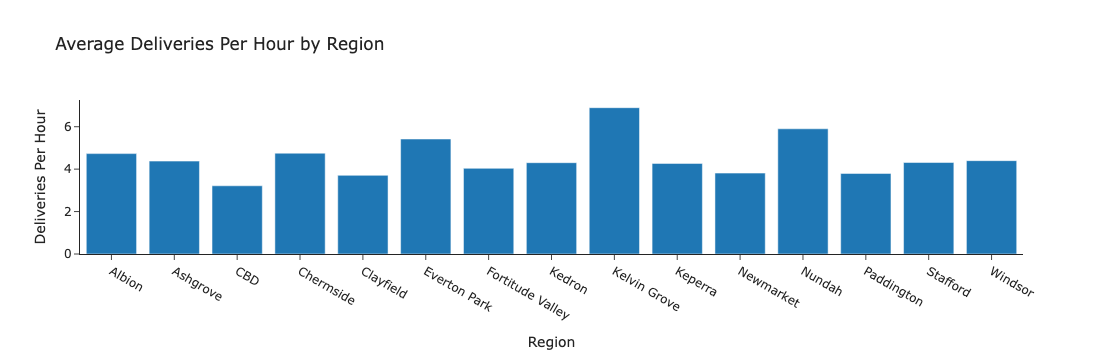

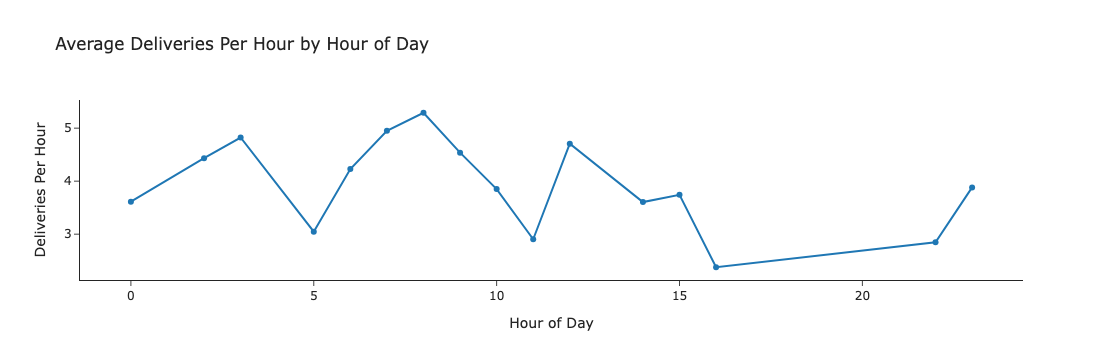

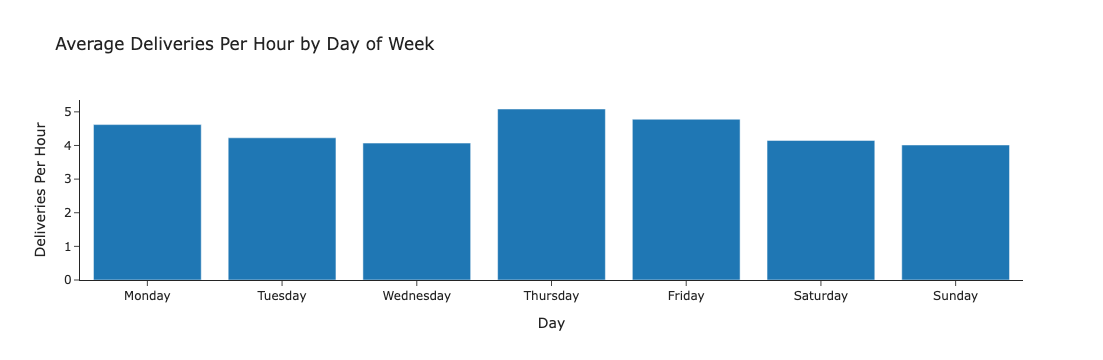

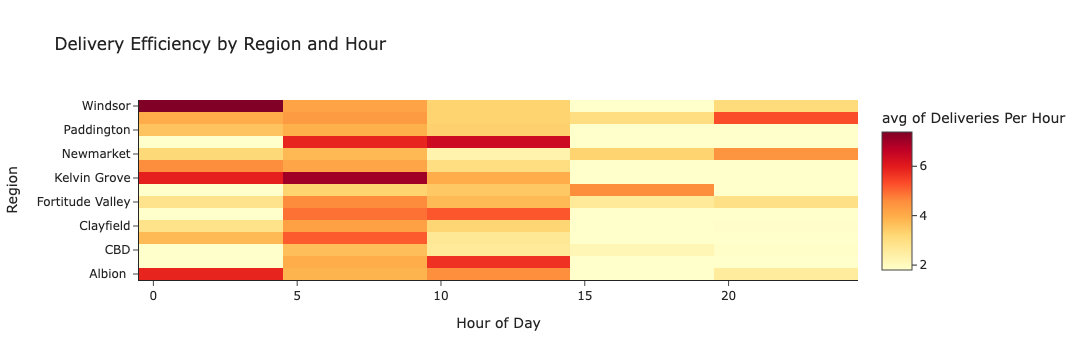

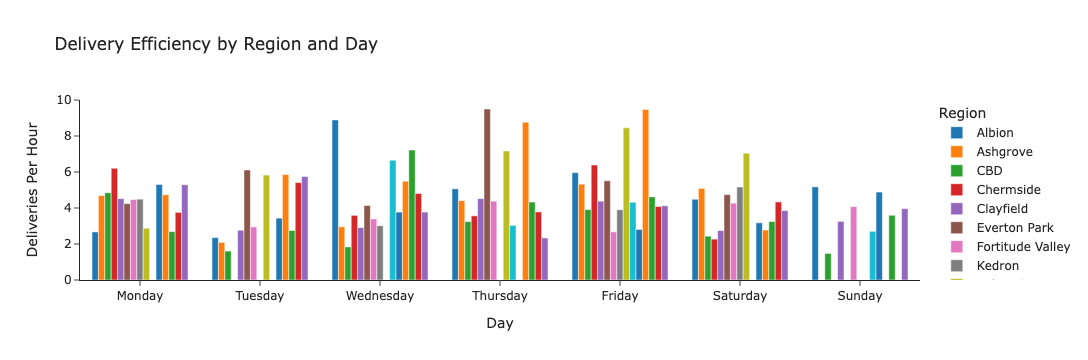

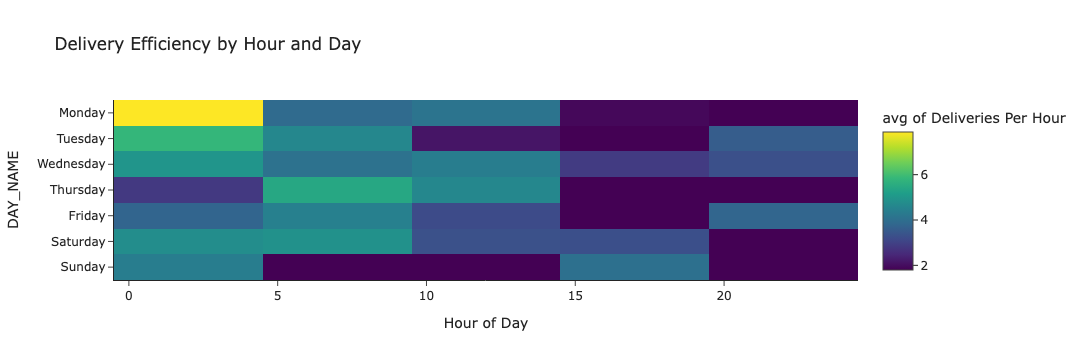

In [40]:
# Set clean visual style
px.defaults.template = "simple_white"

# Correct day order
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]


# Bar chart: delivery efficiency by region
fig = px.bar(
    region_efficiency,
    x="Region",
    y="DELIVERIES_PER_HOUR",
    title="Average Deliveries Per Hour by Region",
    labels={"DELIVERIES_PER_HOUR": "Deliveries Per Hour"}
)
fig.show()


# Line chart: delivery efficiency by hour
fig = px.line(
    hour_efficiency,
    x="HOUR",
    y="DELIVERIES_PER_HOUR",
    markers=True,
    title="Average Deliveries Per Hour by Hour of Day",
    labels={"HOUR": "Hour of Day", "DELIVERIES_PER_HOUR": "Deliveries Per Hour"}
)
fig.show()


# Bar chart: delivery efficiency by day
fig = px.bar(
    day_efficiency,
    x="DAY_NAME",
    y="DELIVERIES_PER_HOUR",
    category_orders={"DAY_NAME": day_order},
    title="Average Deliveries Per Hour by Day of Week",
    labels={"DAY_NAME": "Day", "DELIVERIES_PER_HOUR": "Deliveries Per Hour"}
)
fig.show()


# Heatmap: delivery efficiency by region and hour
fig = px.density_heatmap(
    region_hour_efficiency,
    x="HOUR",
    y="Region",
    z="DELIVERIES_PER_HOUR",
    histfunc="avg",
    color_continuous_scale="YlOrRd",
    title="Delivery Efficiency by Region and Hour",
    labels={
        "HOUR": "Hour of Day",
        "Region": "Region",
        "DELIVERIES_PER_HOUR": "Deliveries Per Hour"
    }
)
fig.show()


# Grouped bar chart: region vs day
fig = px.bar(
    region_day_efficiency,
    x="DAY_NAME",
    y="DELIVERIES_PER_HOUR",
    color="Region",
    barmode="group",
    category_orders={"DAY_NAME": day_order},
    title="Delivery Efficiency by Region and Day",
    labels={"DAY_NAME": "Day", "DELIVERIES_PER_HOUR": "Deliveries Per Hour"}
)
fig.show()


# Heatmap: delivery efficiency by hour and day
fig = px.density_heatmap(
    hour_day_efficiency,
    x="HOUR",
    y="DAY_NAME",
    z="DELIVERIES_PER_HOUR",
    histfunc="avg",
    category_orders={"DAY_NAME": day_order},
    title="Delivery Efficiency by Hour and Day",
    labels={"HOUR": "Hour of Day", "DELIVERIES_PER_HOUR": "Deliveries Per Hour"}
)
fig.show()

### Insight

#### Regional Delivery Efficiency
Kelvin Grove, Nundah, and Everton Park show the highest delivery efficiency, averaging around 6 deliveries per hour. Kelvin Grove may benefit from high restaurant density and easier pickup conditions, allowing drivers to complete orders more quickly.

Nundah and Everton Park may also receive more orders per driver, as their distance from the CBD can result in fewer active drivers competing for deliveries.

In contrast, the CBD records the lowest efficiency (3.2 deliveries per hour). Despite having many restaurants, limited parking, longer walking distances, higher driver competition, and inconsistent wait times likely slow down delivery turnaround.

Most other suburbs average around 4 deliveries per hour, suggesting a balanced environment with moderate restaurant density and relatively manageable pickup conditions.

#### Delivery Efficiency by Day of Week
Delivery efficiency is highest on Thursday (5 deliveries per hour) and Friday (4.8), reflecting stronger order demand toward the end of the work week. Monday (4.6) and Tuesday (4.2) also show strong performance. Wednesday and Sunday both average around 4 deliveries per hour, while Saturday is slightly higher at about 4.1. Efficiency still drops slightly on weekends compared to late-week weekdays, likely due to more drivers working and increasing competition for orders.

#### Delivery Efficiency by Hour of Day
Delivery efficiency generally increases during the morning and peaks around the late morning to lunch period at around 5 deliveries per hour. Early morning hours average around 4 deliveries per hour before dropping to roughly 2.4 deliveries per hour in the early afternoon. Efficiency then recovers slightly during the night to around 3.9 deliveries per hour.

#### Delivery Efficiency by Region and Hour
Delivery efficiency is moderate during early hours (00:00–04:00), with most regions averaging around 3–4 deliveries per hour. Windsor records the highest value during this period at about 7.4 deliveries per hour, reflecting occasional late-night demand.

During the morning period (05:00–09:00), efficiency increases across most regions. Kelvin Grove performs the strongest at around 7 deliveries per hour, followed by Nundah and Chermside at roughly 5.5 deliveries per hour.

Efficiency remains relatively strong during late morning and lunch hours (10:00–14:00). Nundah and Ashgrove show the highest performance during this period at around 6 deliveries per hour, while most other regions average between 3–5 deliveries per hour.

After 15:00, delivery efficiency declines across most regions, with several hours showing very few or zero observations and most regions falling to around 2–3 deliveries per hour. Stafford is an exception later in the evening (20:00–24:00), reaching about 5.3 deliveries per hour. However, the large number of zero values suggests this pattern may partly reflect personal dashing schedules rather than actual demand patterns.

#### Delivery Efficiency by Region and Day
Delivery efficiency varies across regions throughout the week, with several regions showing stronger performance toward the end of the work week. Everton Park records the highest value at around 9.5 deliveries per hour on Thursday, while Nundah and Kelvin Grove also show strong performance on Friday at roughly 9 deliveries per hour.

Weekend performance generally declines across most regions, with several areas falling to around 2.5–3 deliveries per hour. This may reflect more drivers working during these periods, increasing competition for orders, while more people dining out on weekends may also reduce delivery demand.

#### Delivery Efficiency by Hour and Day
Delivery efficiency varies across both hour and day. Monday shows the highest value between 00:00–04:00 at around 7.9 deliveries per hour, representing a late-night outlier. Mid-morning hours (05:00–09:00) remain relatively strong across several days, particularly Thursday and Saturday at around 5 deliveries per hour.

Efficiency generally declines during mid-afternoon and evening hours (15:00 onwards), where several time periods show values around 2 deliveries per hour and multiple zero observations. The presence of many zero values likely reflects personal dashing schedules rather than actual demand patterns.

### Recommendations

- Focus on high-performing regions such as Kelvin Grove, Nundah, and Everton Park, which show the highest average deliveries per hour in the dataset.
- Prioritise late morning and lunch hours (10:00–14:00), where delivery efficiency is consistently highest.
- Consider working more on Thursday and Friday, which show stronger delivery efficiency compared to other days.
- Avoid the Brisbane CBD during busy periods if possible, as parking constraints and higher driver competition reduce efficiency.
- Based on my historical dashing data, this strategy appears most effective for my working style. However, other drivers with similar conditions—particularly motorbike riders who prefer working morning and lunch shifts—may also benefit from focusing on these regions and time periods.

### Limitations

- The dataset is based on my personal delivery history rather than platform-wide DoorDash data, so the findings mainly reflect my own dashing patterns.
- Several hour and day combinations contain very few or zero observations, meaning some patterns may reflect when I chose to dash rather than actual demand conditions.
- The results are more representative of motorbike deliveries, and efficiency patterns may differ for car drivers due to parking constraints and longer walking distances.
- Other operational factors such as restaurant preparation times, traffic conditions, and real-time driver supply were not available in the dataset but may also influence delivery efficiency.

### Final Answer to the Main Question

Based on my historical delivery data, I should focus on dashing in Kelvin Grove, Nundah, or Everton Park, where delivery efficiency has been highest. I should prioritise working during the late morning and lunch period (10:00–14:00), particularly on Thursday and Friday, when deliveries per hour are consistently higher.

This approach aligns well with my preference for working morning shifts on a motorbike, as these areas and time periods allow me to complete deliveries more efficiently. While these findings are based on my own dashing history, drivers with similar working patterns—especially motorbike riders—may also benefit from following a similar strategy.